# RQ3 — Challenges and Support (Q21–Q22)

**Analysis to Address RQ3**: Q21–Q22 — main challenges to guarantee data reliability and frequency of support from other teams.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

sys.path.insert(0, str(Path.cwd()))
import utils as U

U.setup_matplotlib()
TABLES = U.DATA_PROC / "tables"
TABLES.mkdir(exist_ok=True)

df = U.load_anonymized()
print(f"N={len(df)}")


N=56


## Canonical options and helper functions

In [2]:
Q21_OPTIONS = {
    "q21_inconsistency": [
        "Inconsistência entre diferentes fontes de dados",
        "Inconsistency between different data sources",
    ],
    "q21_incompleteness": ["Dados incompletos ou ausentes", "Incomplete or missing data"],
    "q21_no_standard": [
        "Falta de padronização nos formatos de dados",
        "Lack of standardization in data formats",
    ],
    "q21_outdated": ["Dados desatualizados ou não confiáveis", "Outdated or unreliable data"],
    "q21_collection_errors": [
        "Erros introduzidos durante a coleta e processamento",
        "Errors introduced during collection and processing",
    ],
    "q21_traceability": [
        "Dificuldade na rastreabilidade e versionamento dos dados",
        "Difficulty in data traceability and versioning",
    ],
    "q21_no_tools": [
        "Falta de ferramentas adequadas para validação da qualidade dos dados",
        "Lack of adequate tools for validating data quality",
    ],
}
Q21_LABELS = {
    "q21_inconsistency": "Inconsistency across sources",
    "q21_incompleteness": "Incomplete/missing data",
    "q21_no_standard": "Lack of format standardization",
    "q21_outdated": "Outdated/unreliable data",
    "q21_collection_errors": "Errors in collection and processing",
    "q21_traceability": "Difficulty in traceability/versioning",
    "q21_no_tools": "Lack of validation tools",
}


## Q21 — Parsing and Proportions

C:\Users\kevin\AppData\Local\Temp\ipykernel_21740\668755194.py:112: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(pad=0.5)


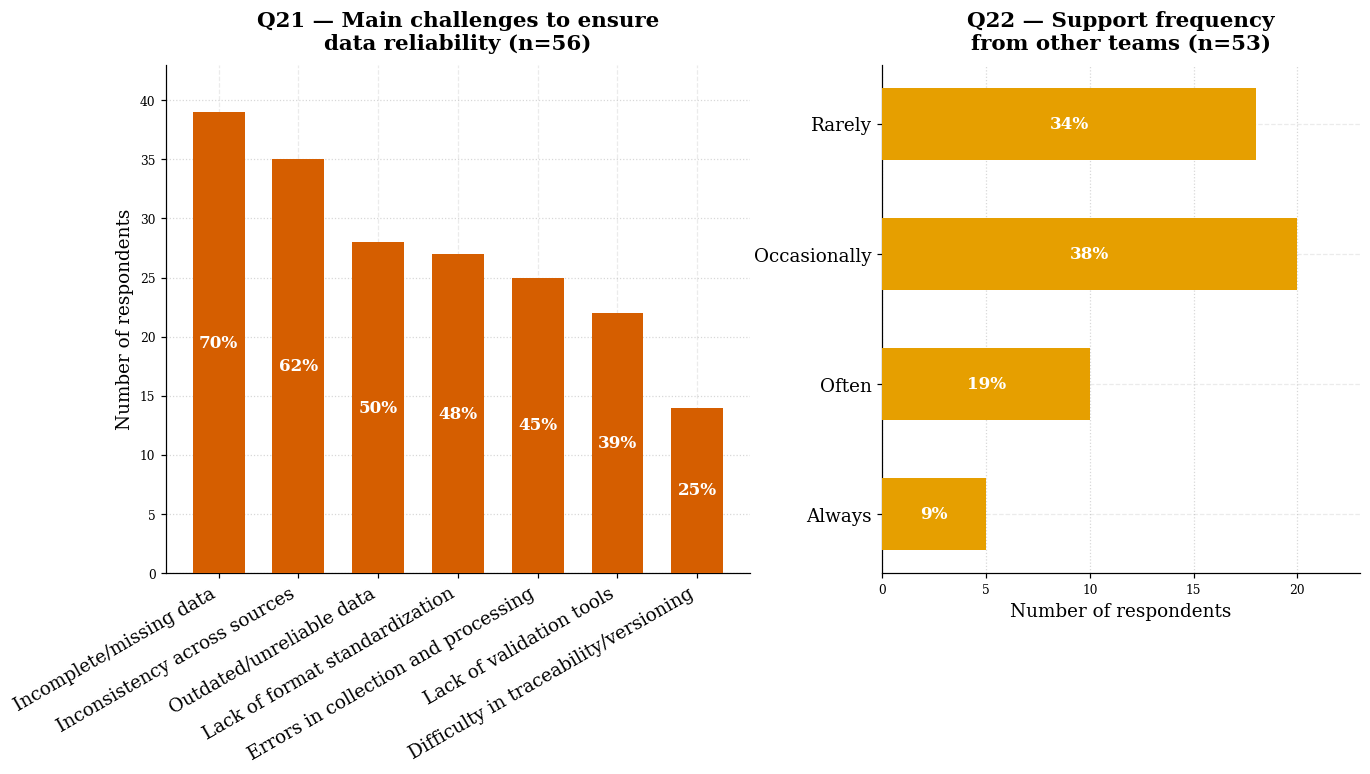

In [3]:
import textwrap

rng = np.random.default_rng(42)

def _boot_ci(values, threshold=4, n_bootstrap=1000, ci_level=0.95):
    values = np.asarray(values)
    n = len(values)
    if n == 0:
        return float("nan"), float("nan")
    alpha = 1 - ci_level
    boot_indices = rng.integers(0, n, size=(n_bootstrap, n))
    boot_props = np.mean(values[boot_indices] >= threshold, axis=1)
    return np.percentile(boot_props, 100 * alpha / 2), np.percentile(boot_props, 100 * (1 - alpha / 2))

def parse_checkboxes(series, options):
    binary = pd.DataFrame(index=series.index, columns=list(options.keys()), dtype=bool)
    binary[:] = False
    residual = series.copy()
    for key, raw in options.items():
        labels = [raw] if isinstance(raw, str) else list(raw)
        present = pd.Series(False, index=series.index)
        for lab in labels:
            present = present | series.fillna("").str.contains(lab, regex=False)
            residual = residual.fillna("").str.replace(lab, "", regex=False)
        binary[key] = present
    residual = residual.str.replace(r"^[,\.\s]+|[,\.\s]+$", "", regex=True)
    residual = residual.where(residual.str.len() > 2, "")
    return binary, residual

def proportions_with_ci(binary, labels, n_total):
    rows = []
    for key in binary.columns:
        vals = binary[key].astype(int).values
        lo, hi = _boot_ci(vals, threshold=1)
        rows.append({
            "key": key, "label": labels[key],
            "n": int(binary[key].sum()),
            "pct": binary[key].mean() * 100,
            "ci_lo": lo * 100, "ci_hi": hi * 100,
        })
    return pd.DataFrame(rows).sort_values("pct", ascending=False).reset_index(drop=True)

# ── Q21 parse ─────────────────────────────────────────────────────────────────
q21_bin, q21_res = parse_checkboxes(df["challenges_open"], Q21_OPTIONS)
n_q21 = df["challenges_open"].notna().sum()
p21 = proportions_with_ci(q21_bin, Q21_LABELS, n_q21)
p21_sorted = p21.sort_values("pct", ascending=False).reset_index(drop=True)

# ── Q22 data ──────────────────────────────────────────────────────────────────
Q22_ORDER  = [4, 3, 2, 1]
Q22_LABELS = ["Always", "Often", "Occasionally", "Rarely"]
q22_counts = df["support_freq"].value_counts(dropna=True).reindex(Q22_ORDER, fill_value=0)
n_q22      = int(q22_counts.sum())
q22_pct    = (q22_counts / n_q22 * 100).values

# ── layout ────────────────────────────────────────────────────────────────────
FS_TITLE = 14
FS_TICK  = 12
FS_BAR   = 11

fig, (ax1, ax2) = plt.subplots(
    1, 2,
    figsize=(14, 6),
    gridspec_kw={"width_ratios": [5.5, 4.5], "wspace": 0.25},
)

# ── Q21 vertical bars (left) ──────────────────────────────────────────────────
x1 = np.arange(len(p21_sorted))
ax1.bar(x1, p21_sorted["n"], color=U.PALETTE_WONG[6], width=0.65, zorder=3)

n_max_q21 = p21_sorted["n"].max()
for i, row in p21_sorted.iterrows():
    ax1.text(i, row["n"] / 2, f"{row['pct']:.0f}%",
             ha="center", va="center", fontsize=FS_BAR, fontweight="bold", color="white")

ax1.set_xticks(x1)
ax1.set_xticklabels(p21_sorted["label"], fontsize=FS_TICK, ha="right", rotation=30)
ax1.set_ylabel("Number of respondents", fontsize=FS_TICK)
ax1.set_ylim(0, n_max_q21 + 4)
ax1.set_title(
    f"Q21 — Main challenges to ensure\ndata reliability (n={n_q21})",
    fontsize=FS_TITLE, fontweight="bold", pad=10,
)
ax1.yaxis.grid(True, linestyle=":", alpha=0.5, zorder=0)
ax1.set_axisbelow(True)
for sp in ["top", "right"]:
    ax1.spines[sp].set_visible(False)

# ── Q22 horizontal bars (right) ───────────────────────────────────────────────
y2 = np.arange(len(Q22_LABELS))
ax2.barh(y2, q22_counts.values, color=U.PALETTE_WONG[1], height=0.55, zorder=3)

n_max_q22 = q22_counts.values.max()
for i, (pct, cnt) in enumerate(zip(q22_pct, q22_counts.values)):
    color = "white" if cnt >= n_max_q22 * 0.2 else "#333333"
    ax2.text(cnt / 2, i, f"{pct:.0f}%",
             ha="center", va="center", fontsize=FS_BAR, fontweight="bold", color=color)

ax2.set_yticks(y2)
ax2.set_yticklabels(Q22_LABELS, fontsize=FS_TICK)
ax2.set_xlabel("Number of respondents", fontsize=FS_TICK)
ax2.set_xlim(0, n_max_q22 + 3)
ax2.set_title(
    f"Q22 — Support frequency\nfrom other teams (n={n_q22})",
    fontsize=FS_TITLE, fontweight="bold", pad=10,
)
ax2.xaxis.grid(True, linestyle=":", alpha=0.5, zorder=0)
ax2.set_axisbelow(True)
for sp in ["top", "right"]:
    ax2.spines[sp].set_visible(False)

fig.tight_layout(pad=0.5)
U.save_fig(fig, "challenges_support_q21_q22")
plt.show()

## Q22 — Support Frequency from Other Teams